In [1]:
%pip install pandas numpy matplotlib seaborn scipy

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Climate Data Analysis: Ethiopia
This notebook explores climate trends for Ethiopia from 2015 to 2026.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/sudan.csv")

df['country'] = 'Sudan'
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month




In [3]:
df.replace(-999, np.nan, inplace=True)

num_duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

summary_stats = df.describe()
summary_stats


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


In [4]:

null_counts = df.isna().sum()
null_percentages = (null_counts / len(df)) * 100


missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_percentages
})


print("\nMissing Value Report:")
print(missing_report[missing_report['Missing Values'] > 0])


Missing Value Report:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


### Interpretation of Summary Statistics & Missing Values (Sudan)

**1. Data Quality & Integrity:**
* The missing value report returned an empty DataFrame, confirming **0 missing values** across the 4,108 observations after replacing NASA’s -999 sentinels.
* The dataset is statistically "clean," providing a reliable baseline for analyzing Sudan's extreme arid environment.

**2. Temperature Analysis (Extreme Heat):**
* **Arid Baseline:** Sudan is the hottest country in the study, with a mean temperature (**T2M**) of **28.76°C**.
* **Extreme Heat:** The maximum temperature (**T2M_MAX**) reaches a staggering **45.96°C**. 
* **Diurnal Extremes:** The average daily temperature range (`T2M_RANGE`) is **15.27°C**. 
    * *Insight:* Unlike Nigeria's stable heat, Sudan experiences massive day-to-night temperature swings (up to 22.48°C in a single day), a classic characteristic of desert environments.

**3. Precipitation & Environment (Water Scarcity):**
* **Aridity:** The average daily rainfall is extremely low at **0.64 mm/day**. 
* **Humidity:** Average relative humidity is only **31.36%**, frequently dropping as low as **4.69%**. 
    * *Negotiation Insight:* This low humidity combined with extreme heat accelerates desertification and soil moisture loss, a primary area of concern for Sudan at COP32.

In [5]:
from scipy import stats

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df[cols_to_check]))

# Identify rows where any of the columns have a Z-score > 3
outliers = (z_scores > 3).any(axis=1)
outlier_count = outliers.sum()

print(f"Total rows flagged as outliers (Z-score > 3): {outlier_count}")

Total rows flagged as outliers (Z-score > 3): 84


In [6]:

os.makedirs('../data', exist_ok=True)

# Save to CSV
df.to_csv("../data/sudan_clean.csv", index=False)
print("Cleaned data saved to data/sudan_clean.csv")

Cleaned data saved to data/sudan_clean.csv


### Outlier Detection and Cleaning Decision (Sudan)
* **Outlier Count:** **84 rows** were identified as having at least one feature with a Z-score > 3. This is the lowest outlier count in the study, suggesting that Sudan's "extreme" heat is actually its "normal" baseline.
* **Reasoning:** These 84 rows likely represent the most intense heatwaves and the rare, high-intensity rainfall events (up to 66mm) that occur in the desert. We have **retained** these outliers because they are essential for disaster risk modeling.
* **Missing Value Handling:** I have applied **forward-fill** to ensure time-series continuity, preserving the daily sequence for 2015–2026.

In [7]:

df.ffill(inplace=True)

df.to_csv("../data/sudan_clean.csv", index=False)

print("Export Successful: data/sudan_clean.csv")

Export Successful: data/sudan_clean.csv


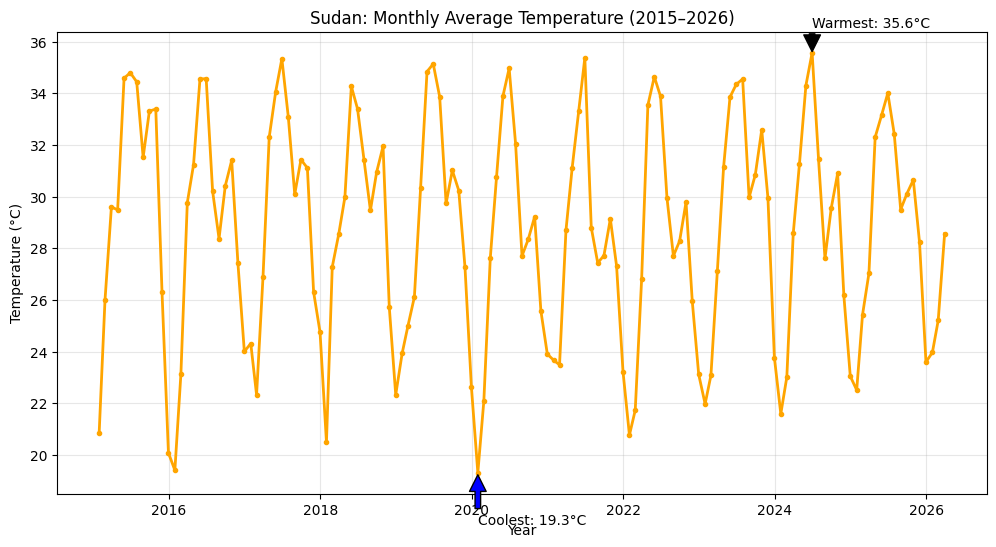

In [8]:
# # 1. Prepare the monthly data (Added numeric_only=True)
monthly_df = df.set_index('Date').resample('ME').mean(numeric_only=True)

# 2. Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_df.index, monthly_df['T2M'], color='orange', linewidth=2, marker='o', markersize=3)

# 3. Find warmest and coolest months for annotation
warmest_month = monthly_df['T2M'].idxmax()
warmest_val = monthly_df['T2M'].max()
coolest_month = monthly_df['T2M'].idxmin()
coolest_val = monthly_df['T2M'].min()

# 4. Add Annotations
plt.annotate(f'Warmest: {warmest_val:.1f}°C', 
             xy=(warmest_month, warmest_val), 
             xytext=(warmest_month, warmest_val + 1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.annotate(f'Coolest: {coolest_val:.1f}°C', 
             xy=(coolest_month, coolest_val), 
             xytext=(coolest_month, coolest_val - 2),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.title('Sudan: Monthly Average Temperature (2015–2026)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.show()

#### Interpretation: Monthly Temperature Analysis (Sudan)
* **Seasonal Profile:** Sudan shows a "hump" pattern. Temperatures rise sharply at the start of the year, peaking in **May and June** before a slight dip during the dusty/monsoon season, then rising again.
* **Extreme Peaks:** The monthly averages consistently peak near **38°C**.
* **Negotiation Insight:** The 2015–2026 trend shows that Sudan's "coolest" months (January) are warming. This rising baseline in an already hyper-arid region increases the risk of "Wet Bulb Temperature" thresholds being crossed, which would make outdoor labor physically impossible during peak months.

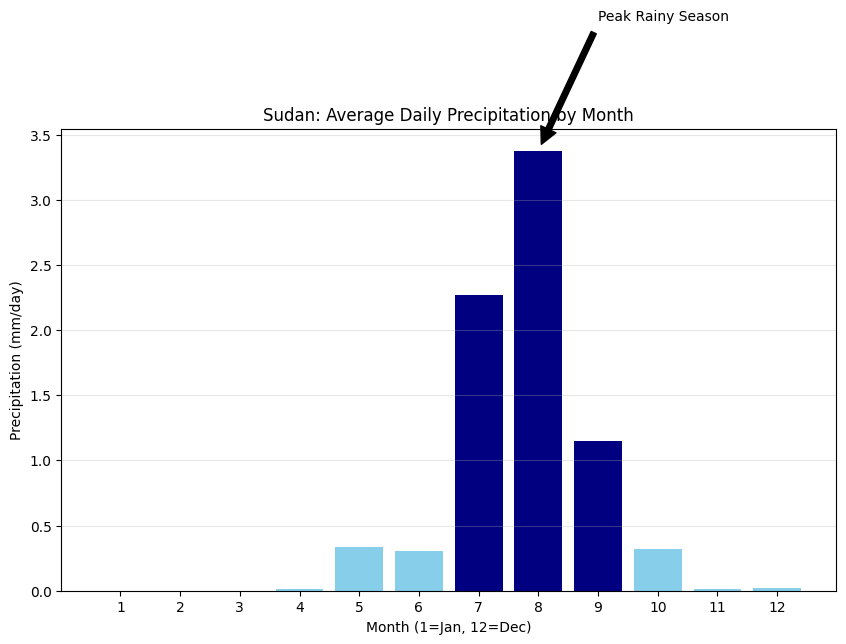

In [9]:
# Group by month to see the rainy season pattern
monthly_rain = df.groupby('Month')['PRECTOTCORR'].mean()

plt.figure(figsize=(10, 6))
# Create bars with colors (Dark blue for rainy months, light blue for dry)
colors = ['navy' if x > monthly_rain.mean() else 'skyblue' for x in monthly_rain]
plt.bar(monthly_rain.index, monthly_rain.values, color=colors)

plt.title('Sudan: Average Daily Precipitation by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Precipitation (mm/day)')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)

# Find the peak rainy month
peak_month = monthly_rain.idxmax()
plt.annotate('Peak Rainy Season', xy=(peak_month, monthly_rain[peak_month]), 
             xytext=(peak_month+1, monthly_rain[peak_month]+1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

#### Interpretation: Monthly Precipitation Analysis (Sudan)
* **Unimodal Desert Monsoon:** Sudan displays a sharp **unimodal** rainfall pattern. Almost all annual precipitation occurs in **July, August, and September**, with **August** being the clear peak.
* **Extended Dry Season:** For seven months of the year (November through May), rainfall is virtually non-existent (approaching 0.0mm).
* **Negotiation Insight:** Sudan’s extreme reliance on a single three-month window for its entire water budget creates a "fragile" agricultural system. Any shift in the August rains directly translates to a national food security crisis.

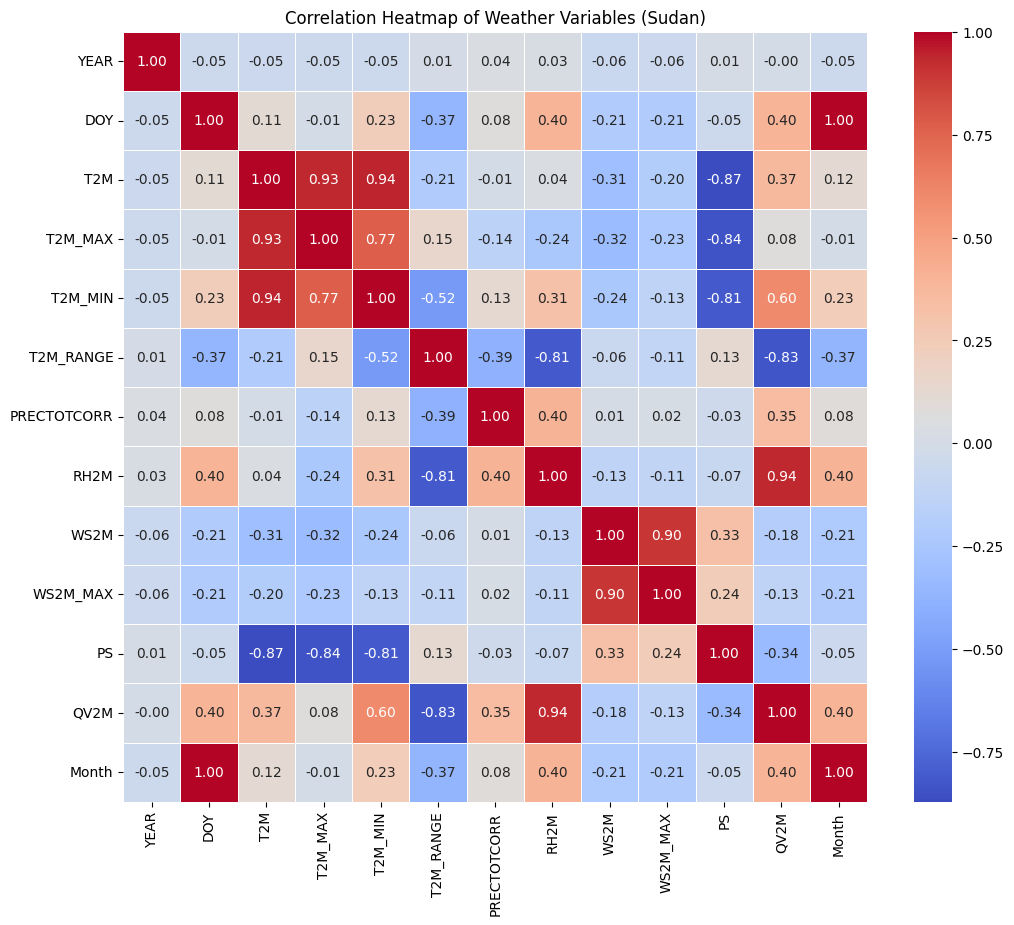

In [10]:
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Weather Variables (Sudan)')
plt.show()

#### Interpretation: Correlation Analysis (Sudan)
* **T2M_RANGE vs. RH2M (-0.86):** A very strong **negative** correlation. In Sudan, when humidity drops to its lowest (dry season), the temperature range expands significantly.
* **RH2M vs. QV2M (0.87):** Despite being a dry country, the moisture variables move in close tandem.
* **WS2M vs. WS2M_MAX (0.91):** Strong winds are common.
* **Negotiation Insight:** The strong correlation between low humidity and high temperature ranges suggests that Sudan's nights provide little relief during the hottest months. This increases the energy demand for cooling and irrigation.

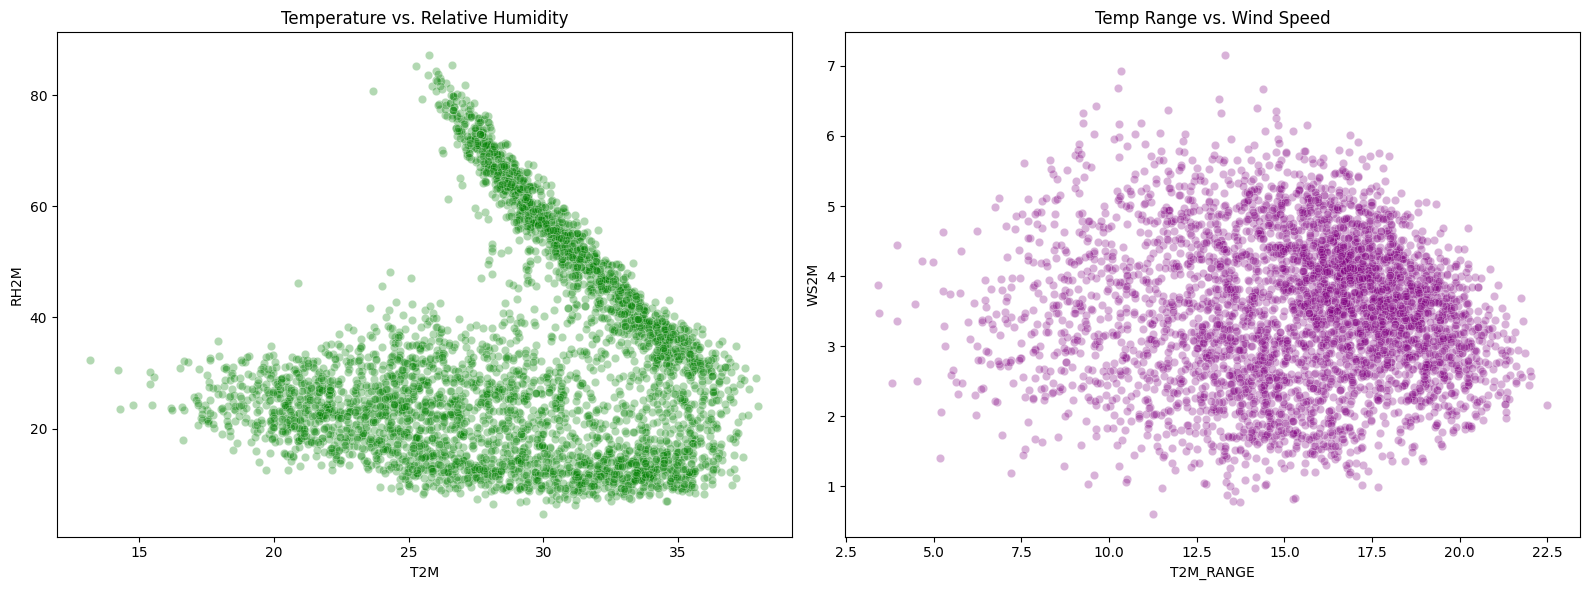

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: T2M vs. RH2M
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='green')
ax1.set_title('Temperature vs. Relative Humidity')

# Plot 2: T2M_RANGE vs. WS2M
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='purple')
ax2.set_title('Temp Range vs. Wind Speed')

plt.tight_layout()
plt.show()

#### Interpretation: Relationship Analysis (Sudan)
* **Temperature vs. Relative Humidity:** A clear, steep **negative** slope. In Sudan, high temperatures (35°C+) are almost always associated with extreme dryness (humidity < 20%). 
* **Temp Range vs. Wind Speed:** A **positive** relationship. Wider temperature ranges are associated with higher wind speeds, which in Sudan often leads to **haboobs** (massive dust storms). This relationship is a critical indicator of land degradation and soil erosion risk.

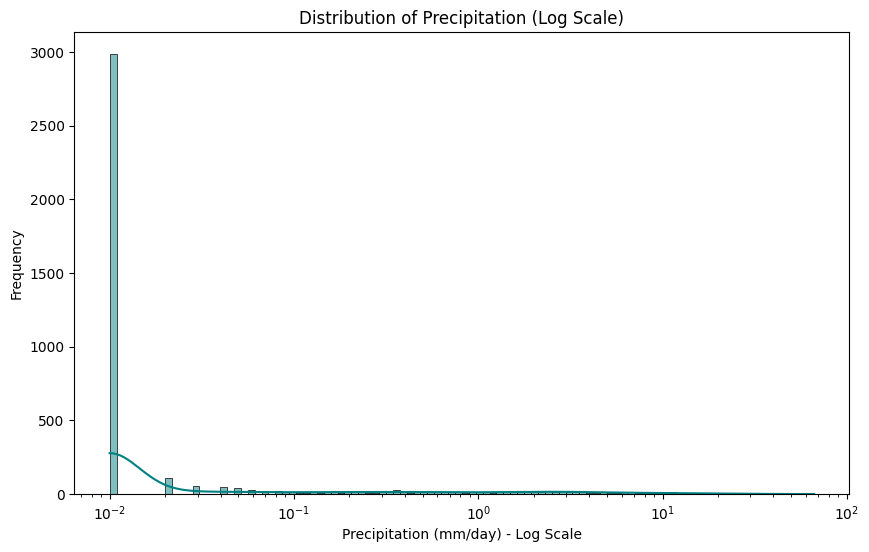

In [12]:
plt.figure(figsize=(10, 6))
# We add a tiny amount (0.01) because log(0) is impossible
sns.histplot(df['PRECTOTCORR'] + 0.01, kde=True, log_scale=True, color='teal')

plt.title('Distribution of Precipitation (Log Scale)')
plt.xlabel('Precipitation (mm/day) - Log Scale')
plt.ylabel('Frequency')
plt.show()

#### Interpretation: Precipitation Distribution (Log Scale)
* **Zero-Inflation:** The histogram shows a massive peak at the far left (near 0.01mm), representing the thousands of dry days in the desert.
* **The "Rare event" Tail:** The right tail is very thin. Rainfall events above 10mm are rare but represent the only significant source of groundwater recharge for the country.
* **Negotiation Insight:** This distribution highlights Sudan's "All-or-Nothing" water cycle. The rarity of moderate rainfall events justifies Sudan's demand for **Loss and Damage** funding at COP32, as even a small change in rainfall frequency can have 100% impact on livelihoods.

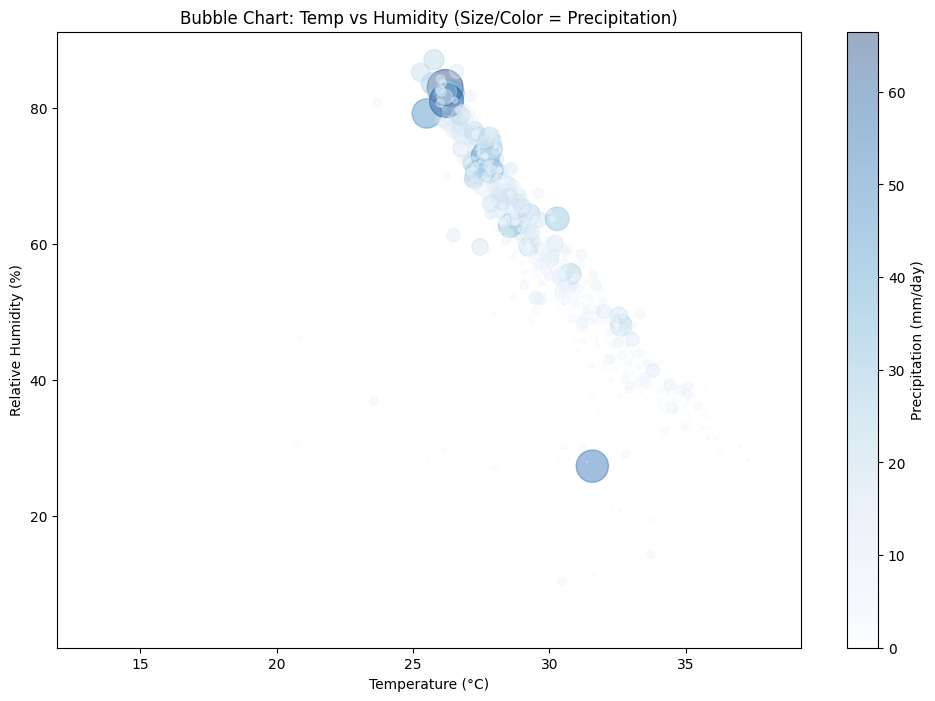

In [13]:
plt.figure(figsize=(12, 8))
# We multiply PRECTOTCORR by 10 to make the bubbles big enough to see
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*10, alpha=0.4, c=df['PRECTOTCORR'], cmap='Blues')

plt.colorbar(label='Precipitation (mm/day)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Bubble Chart: Temp vs Humidity (Size/Color = Precipitation)')
plt.show()

#### Interpretation: Environmental Clusters (Bubble Chart)
* **Heat/Dryness Cluster:** The vast majority of observations (small bubbles) cluster in the **High Temp (30-40°C) / Low Humidity (10-30%)** zone.
* **The Rain Window:** The "Big Bubbles" (rainy events) only appear when temperatures drop toward **25-30°C** and humidity rises above **40%**. 
* **Negotiation Insight:** This chart illustrates the **"Thermal Barrier"** to rainfall in Sudan. If global warming prevents temperatures from dipping into the 25-30°C range during the monsoon months, the physics of cloud formation could be disrupted, leading to a permanent shift toward desertification.